In [119]:
# Import 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, mean_squared_error, mean_absolute_error, r2_score, silhouette_score

sns.set(style="whitegrid")

In [120]:
# Load data 

df = pd.read_excel("Healthcare_dataset_cleaned.xlsx")

In [121]:
# Drop columns 

df = df.drop(columns=["Name", "Date_of_Admission", "Doctor", "Hospital", "Room_Number", "Discharge_Date", "Age_Group"])

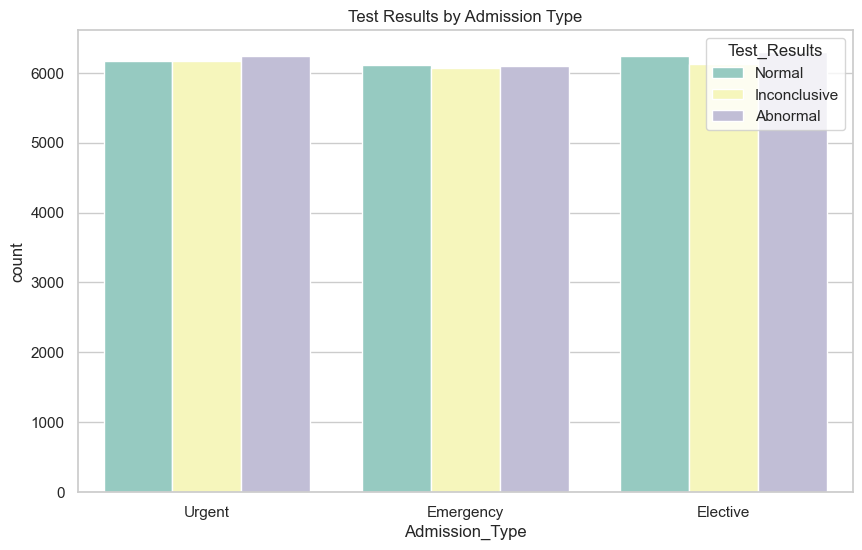

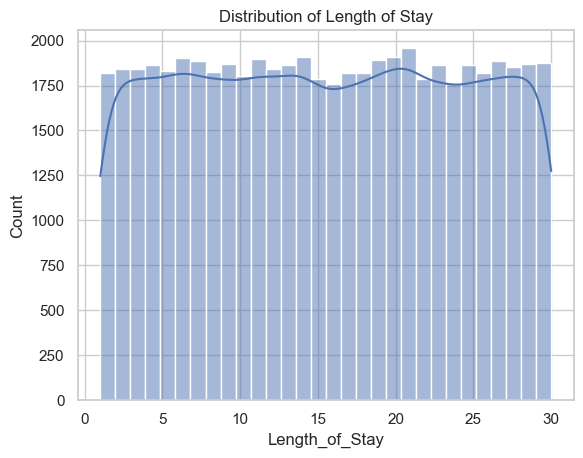

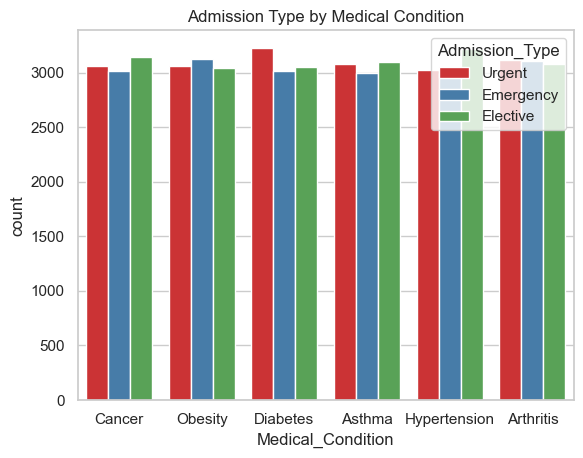

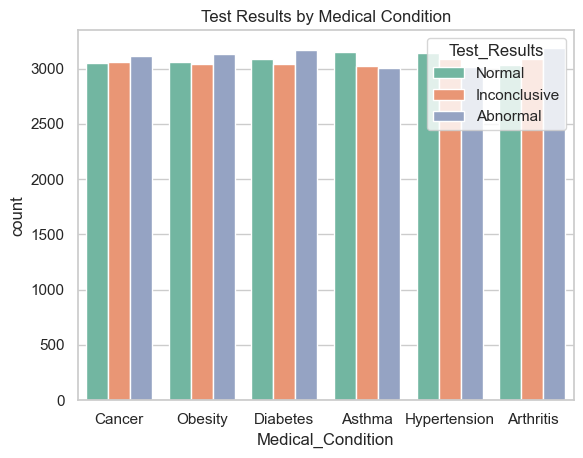

In [122]:
# EDA Visualizations 

# 1. Test Results by Admission Type
plt.figure(figsize=(10,6))
sns.countplot(x="Admission_Type", hue="Test_Results", data=df, palette="Set3")
plt.title("Test Results by Admission Type")
plt.show()

# 2. Distribution of Length of Stay 
sns.histplot(df["Length_of_Stay"], kde=True, bins=30)
plt.title("Distribution of Length of Stay")
plt.show()

# 3. Admission Type by Medical Condition 
sns.countplot(x="Medical_Condition", hue="Admission_Type", data=df, palette="Set1")
plt.title("Admission Type by Medical Condition")
plt.show()

# 4. Test Results by Medical Condition
sns.countplot(x="Medical_Condition", hue="Test_Results", data=df, palette="Set2")
plt.title("Test Results by Medical Condition")
plt.show()

In [123]:
# Encode categorical columms 
label_cols = ["Gender", "Blood_Type", "Medical_Condition", "Insurance_Provider", "Admission_Type", "Medication", "Test_Results"]
encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le 

# Scale numeric columns
scaler = StandardScaler()
df[["Age_scaled", "Billing_scaled"]] = scaler.fit_transform(df[["Age", "Billing_Amount"]])

In [124]:
# Q1. Can we predict a patient’s test result category based on the given variables?  (age, gender, blood_type, medical_condition, insurance_provider, billing_amount, admission_type, medication) 
# Classification 

X1 = df[["Age_scaled", "Gender", "Blood_Type", "Medical_Condition", "Insurance_Provider", "Billing_scaled", "Admission_Type", "Medication"]] 
Y1 = df["Test_Results"]

X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.3, random_state=42, stratify=Y1)

In [125]:
models_Q1 = {}

In [126]:
# Logistic Regression 

log_clf_params = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs"]}
log_clf = GridSearchCV(LogisticRegression(max_iter=500), log_clf_params, cv=5, scoring="accuracy")
log_clf.fit(X1_train, Y1_train)
models_Q1["Logistic Regression"] = log_clf.best_estimator_

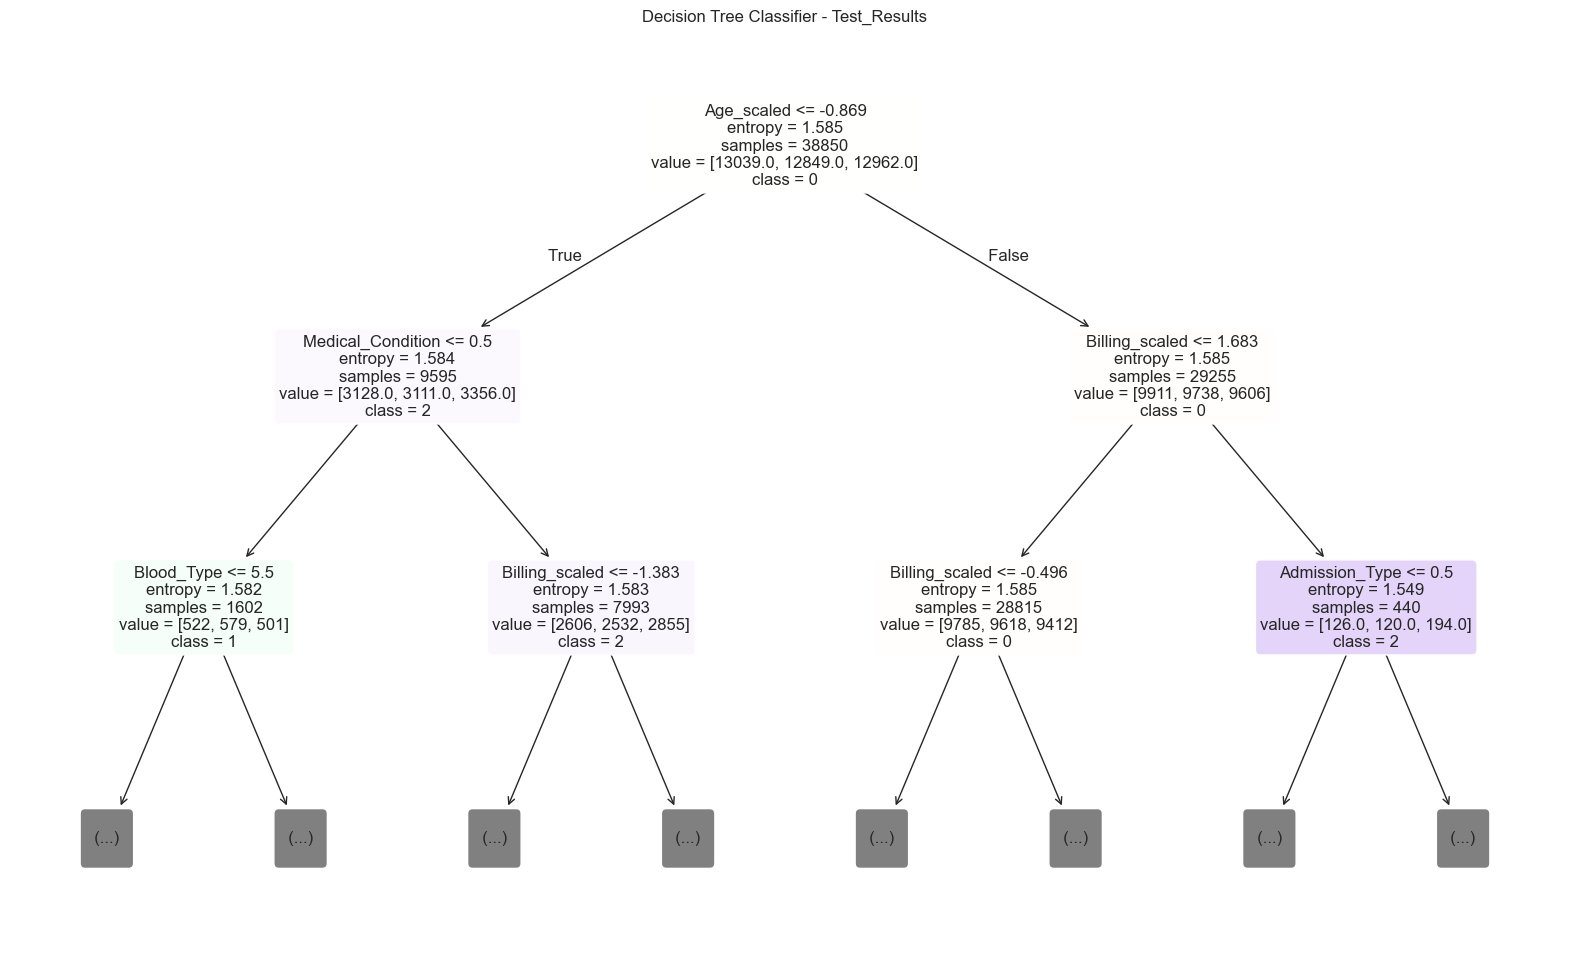

In [127]:
# Decision Tree 

dt_clf_params = {"max_depth": [3, 5, 7, None], "criterion": ["gini", "entropy"]}
dt_clf = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_clf_params, cv=5, scoring="accuracy")
dt_clf.fit(X1_train, Y1_train)
models_Q1["Decision Tree"] = dt_clf.best_estimator_

dt_clf_model = models_Q1["Decision Tree"]

plt.figure(figsize=(20,12))
plot_tree(dt_clf_model, feature_names=X1.columns, class_names=[str(cls) for cls in np.unique(Y1)], filled=True, rounded=True, max_depth=2, fontsize=12)
plt.title("Decision Tree Classifier - Test_Results")
plt.show()

In [128]:
# Random Forest 

rf_clf = GridSearchCV((RandomForestClassifier(random_state=42, n_jobs=-1)), param_grid={"n_estimators": [100, 200], "max_depth": [10, 20, None]}, cv=5, scoring="accuracy")
rf_clf.fit(X1_train, Y1_train)
models_Q1["Random Forest"] = rf_clf.best_estimator_

In [129]:
# KNN 

knn_clf_params = {"n_neighbors": list(range(3,21,2))}
knn_clf = GridSearchCV(KNeighborsClassifier(), knn_clf_params, cv=5, scoring="accuracy")
knn_clf.fit(X1_train, Y1_train)
models_Q1["KNN"] = knn_clf.best_estimator_

In [130]:
# Evaluate models 

results_Q1 = {}

for name, model in models_Q1.items():
    preds = model.predict(X1_test)
    probs = model.predict_proba(X1_test)

    results_Q1[name] = {"preds": preds, "probs": probs, "accuracy": accuracy_score(Y1_test, preds), "precision": precision_score(Y1_test, preds, average="macro"), "recall": recall_score(Y1_test, preds, average="macro"), "f1": f1_score(Y1_test, preds, average="macro")}

In [131]:
# Select best model 

best_Q1 = max(results_Q1, key=lambda x: results_Q1 [x] ["accuracy"])
best_model_Q1 = models_Q1[best_Q1]

print(f"Q1. Best Model: {best_Q1}")
print(f"Accuracy: {results_Q1[best_Q1]['accuracy']:.3f}")
print(f"Precision: {results_Q1[best_Q1]['precision']:.3f}")
print(f"Recall: {results_Q1[best_Q1]['recall']:.3f}")
print(f"F1 Score: {results_Q1[best_Q1]['f1']:.3f}")

Q1. Best Model: Random Forest
Accuracy: 0.417
Precision: 0.417
Recall: 0.417
F1 Score: 0.417


Logistic Regression: Accuracy = 0.331
Decision Tree: Accuracy = 0.389
Random Forest: Accuracy = 0.417
KNN: Accuracy = 0.372


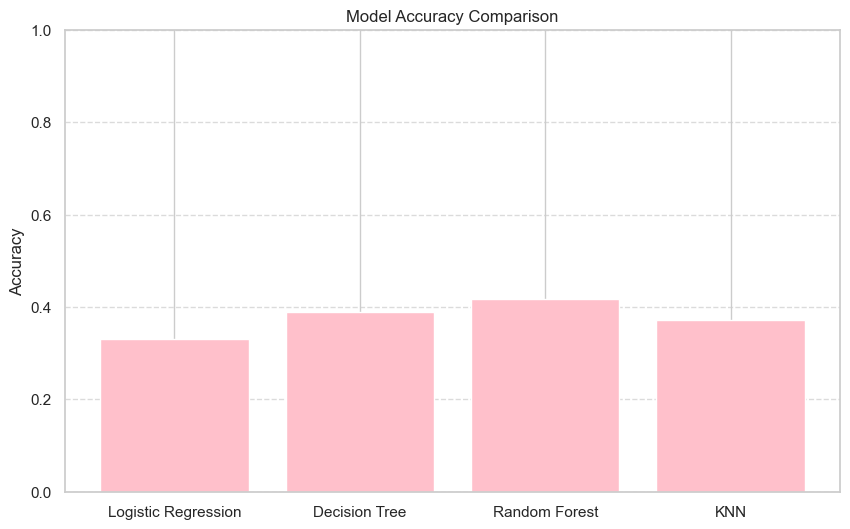

In [132]:
# Accuracy comparision across models - Q1. 

modelnames_Q1 = list(results_Q1.keys())
accuracies = [results_Q1[name]['accuracy'] for name in modelnames_Q1]

for name in modelnames_Q1:
    print(f"{name}: Accuracy = {results_Q1[name]['accuracy']:.3f}")

plt.figure(figsize=(10,6))
plt.bar(modelnames_Q1, accuracies, color='pink')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

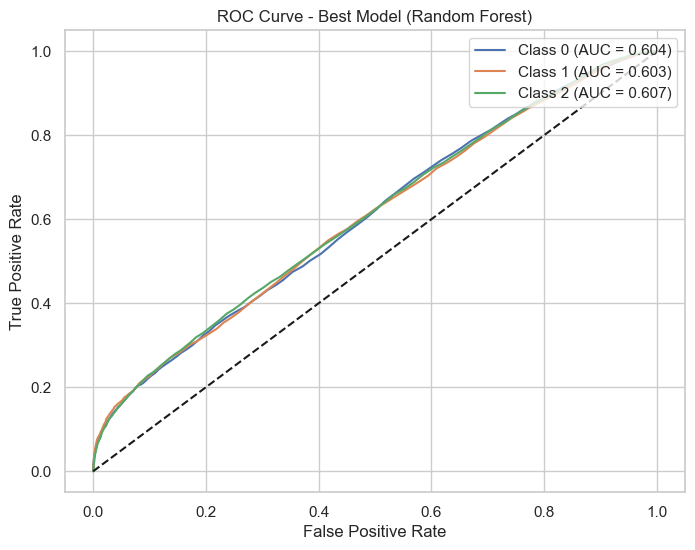

In [133]:
# ROC Curve for Best Model 

Y1_test_bin = label_binarize(Y1_test, classes=np.unique(Y1_test))
probs_best = results_Q1[best_Q1]["probs"]
plt.figure(figsize=(8,6))
class_labels = np.unique(Y1_test)
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(Y1_test_bin[:,i], probs_best[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_labels[i]} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title(f"ROC Curve - Best Model ({best_Q1})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

In [134]:
# Q2. Can a patient’s length of stay be predicted based on these factors? (age, gender, blood_type, medical_condition, insurance_provider, billing_amount, admission_type, medication)
# Regression 

X2 = df[["Age_scaled", "Gender", "Blood_Type", "Medical_Condition", "Insurance_Provider", "Billing_scaled", "Admission_Type", "Medication"]] 
Y2 = df["Length_of_Stay"]

X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.3, random_state=42)

In [135]:
models_Q2 = {}

In [136]:
# Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X2_train, Y2_train)
models_Q2["Linear Regression"] = lin_reg

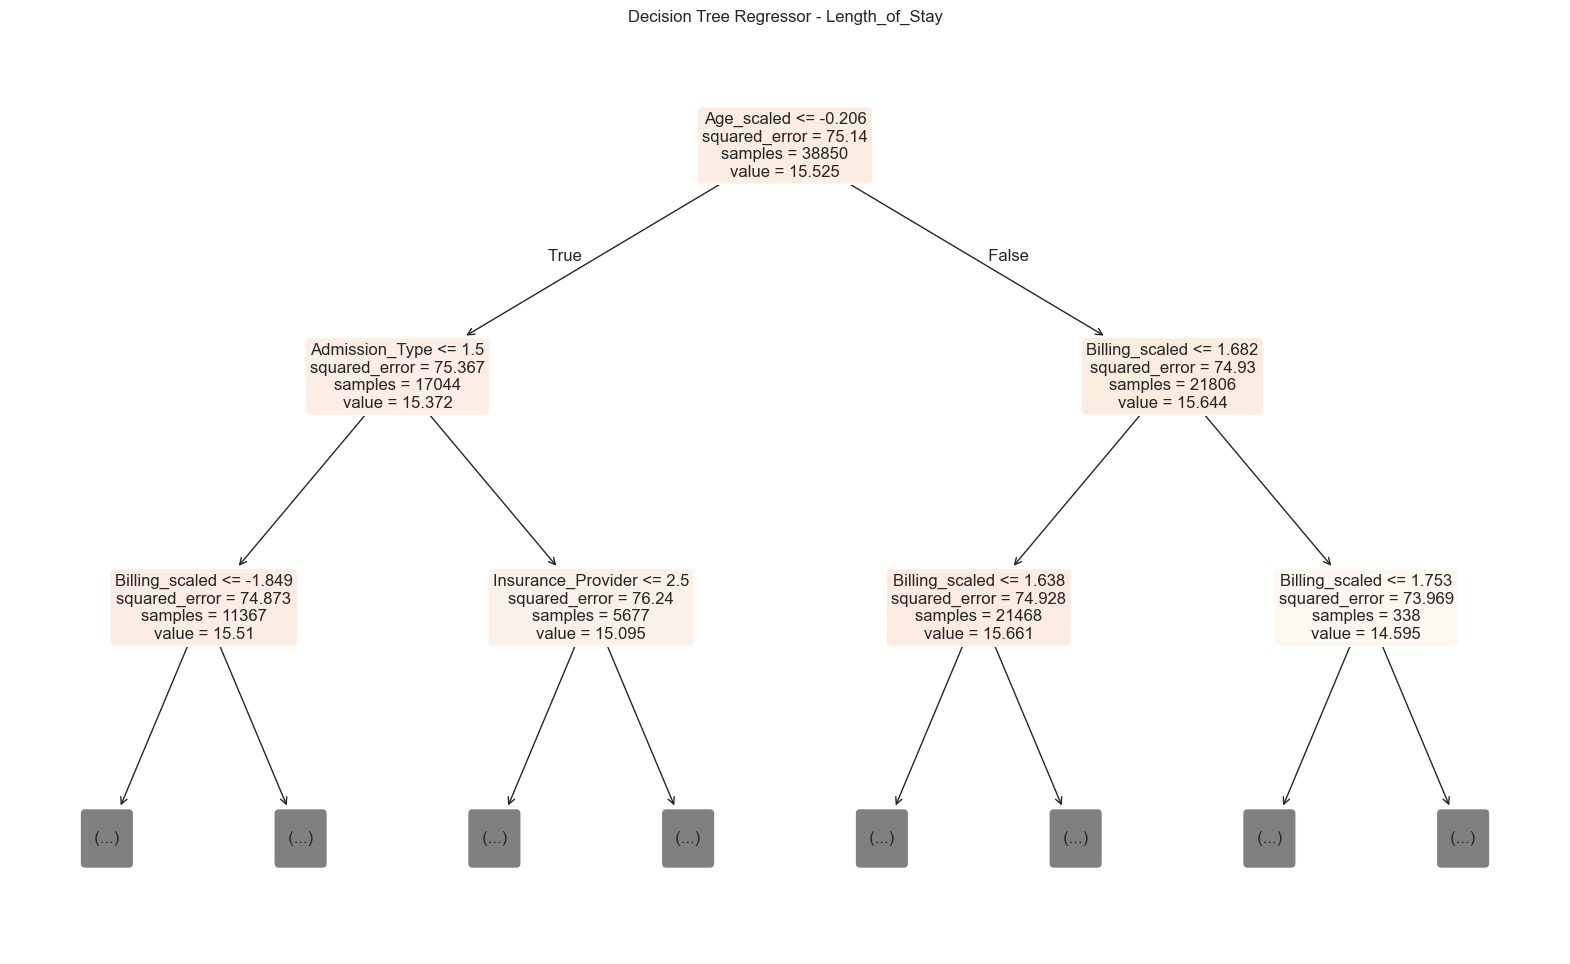

In [137]:
# Decision Tree 

dt_reg_params = {"max_depth":[3, 5, 7, None]}
dt_reg = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_reg_params, cv=5, scoring="r2")
dt_reg.fit(X2_train, Y2_train)
models_Q2["Decision Tree"] = dt_reg.best_estimator_

dt_reg_model = models_Q2["Decision Tree"]

plt.figure(figsize=(20,12))
plot_tree(dt_reg_model, feature_names=X2.columns, filled=True, rounded=True, max_depth=2, fontsize=12)
plt.title("Decision Tree Regressor - Length_of_Stay")
plt.show()

In [138]:
# Random Forest 

rf_reg = GridSearchCV((RandomForestRegressor(random_state=42, n_jobs=-1)), param_grid={"n_estimators": [100, 200], "max_depth": [10, 20, None]}, cv=5, scoring="r2")
rf_reg.fit(X2_train, Y2_train)
models_Q2["Random Forest"] = rf_reg.best_estimator_

In [139]:
# KNN 

knn_reg_params = {"n_neighbors": list(range(3,21,2))}
knn_reg = GridSearchCV(KNeighborsRegressor(), knn_reg_params, cv=5, scoring="r2")
knn_reg.fit(X2_train, Y2_train)
models_Q2["KNN"] = knn_reg.best_estimator_

In [140]:
# Evaluate models 

results_Q2 = {}

for name, model in models_Q2.items():
    preds = model.predict(X2_test)

    results_Q2[name] = {"preds": preds, "r2": r2_score(Y2_test, preds), "mse": mean_squared_error(Y2_test, preds), "rmse": np.sqrt(mean_squared_error(Y2_test, preds)), "mae": mean_absolute_error(Y2_test, preds)}

In [141]:
# Select best model 

best_Q2 = max(results_Q2, key=lambda x: results_Q2 [x] ["r2"])
best_model_Q2 = models_Q2[best_Q2]

print(f"Q2. Best Model: {best_Q2}")
print(f"R2: {results_Q2[best_Q2]['r2']:.3f}")
print(f"MSE: {results_Q2[best_Q2]['mse']:.3f}")
print(f"RMSE: {results_Q2[best_Q2]['rmse']:.3f}")
print(f"MAE: {results_Q2[best_Q2]['mae']:.3f}")

Q2. Best Model: Random Forest
R2: 0.045
MSE: 71.301
RMSE: 8.444
MAE: 7.191


In [174]:
# Q3. How can patients be grouped into distinct clusters based on the given variables (age, gender, medical condition, and insurance provider), and how do these segments differ?
# Clustering

X3_encoded = pd.get_dummies(df[["Gender", "Medical_Condition", "Insurance_Provider"]], columns=["Medical_Condition", "Insurance_Provider"], drop_first=True)

X3 = X3_encoded.copy()
X3["Age"] = df["Age"]

In [176]:
# Elbow method 

inertia_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=3)
    kmeans.fit(X3)
    inertia_scores.append(kmeans.inertia_)

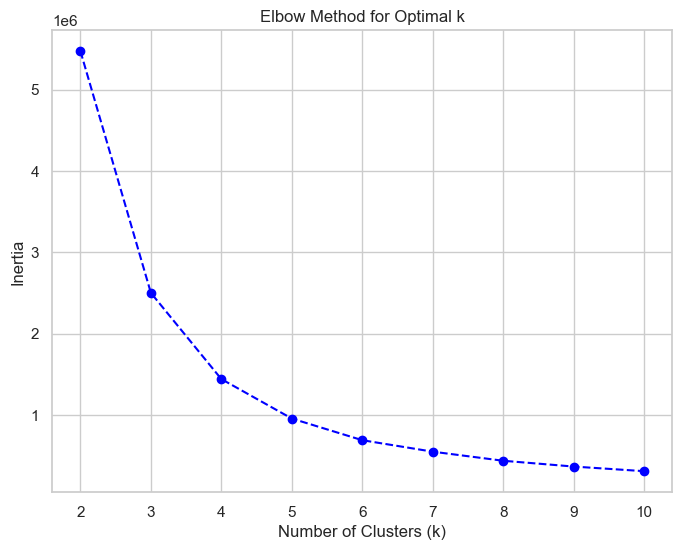

In [177]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--', color='blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [178]:
# Silhouette Score 

silhouette_scores = []
k_range2 = range(2,11)

for k in k_range2:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=3)
    labels = kmeans.fit_predict(X3)
    sil = silhouette_score(X3, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(sil)

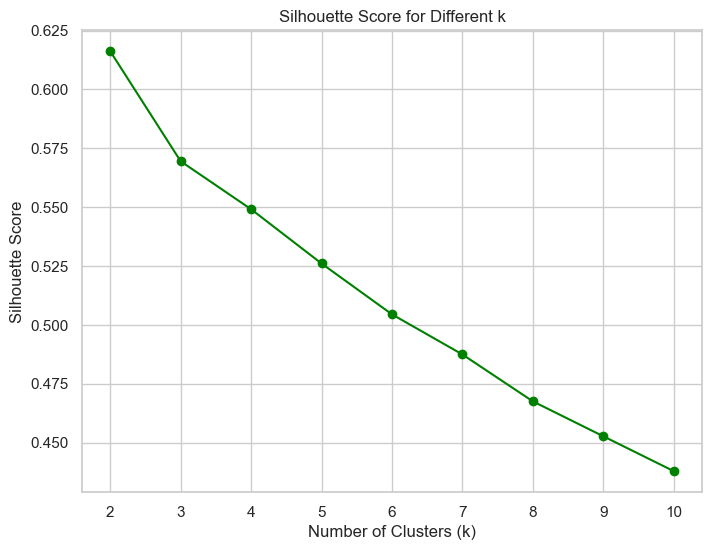

In [179]:
plt.figure(figsize=(8, 6))
plt.plot(k_range2, silhouette_scores, marker='o', linestyle='-', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.grid(True)
plt.show()

In [191]:
optimal_k_silhouette = k_range2[np.argmax(silhouette_scores)]
print("Optimal k based on Silhouette Score:", optimal_k_silhouette)

Optimal k based on Silhouette Score: 2


In [192]:
kmeans_final = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X3)

In [193]:
print("\nCluster Counts:")
print(df['Cluster'].value_counts().sort_index().to_string(header=False))


Cluster Counts:
0    27869
1    27631


In [194]:
cluster_means = df.groupby("Cluster")[["Age", "Length_of_Stay"]].mean().round(3)
print("Average")
print(cluster_means)

Average
            Age  Length_of_Stay
Cluster                        
0        68.415          15.588
1        34.518          15.429


In [195]:
label_cols = ["Gender", "Medical_Condition", "Insurance_Provider", "Test_Results"]
for col in label_cols:
    df[col + "_Label"] = encoders[col].inverse_transform(df[col])


Gender Distribution by Cluster:
Gender_Label  Female   Male
Cluster                    
0              13908  13961
1              13818  13813


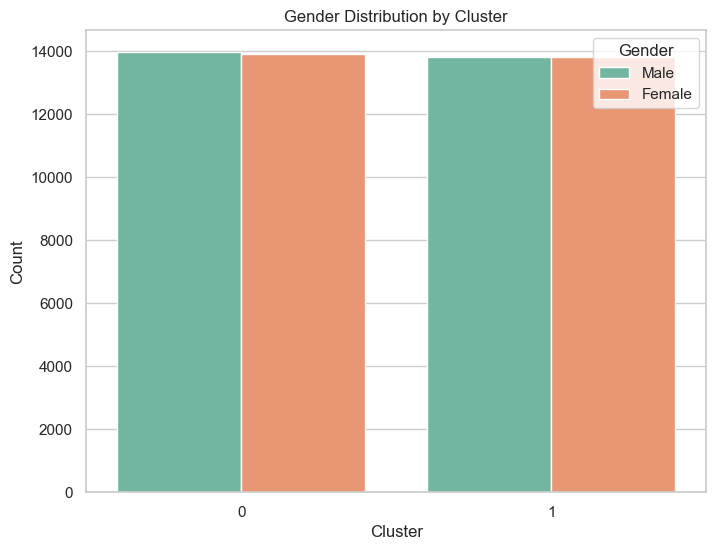

In [196]:
gender_by_cluster = pd.crosstab(df['Cluster'], df['Gender_Label'])
print("\nGender Distribution by Cluster:")
print(gender_by_cluster)

plt.figure(figsize=(8,6))
sns.countplot(x="Cluster", hue="Gender_Label", data=df, palette="Set2")
plt.title("Gender Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()


Insurance Provider Distribution by Cluster:
Insurance_Provider_Label  Aetna  Blue Cross  Cigna  Medicare  UnitedHealthcare
Cluster                                                                       
0                          5527        5588   5589      5590              5575
1                          5386        5471   5660      5564              5550


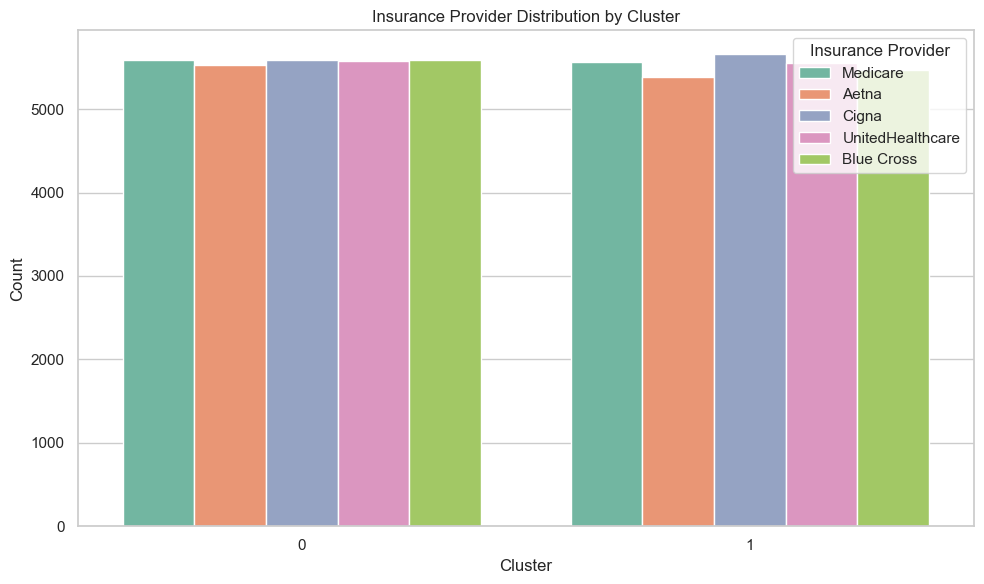

In [197]:
insurance_by_cluster = pd.crosstab(df['Cluster'], df['Insurance_Provider_Label'])
print("\nInsurance Provider Distribution by Cluster:")
print(insurance_by_cluster)

plt.figure(figsize=(10,6))
sns.countplot(x="Cluster", hue="Insurance_Provider_Label", data=df, palette="Set2")
plt.title("Insurance Provider Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Insurance Provider")
plt.tight_layout()
plt.show()


Test Results Distribution by Cluster:
Test_Results_Label  Abnormal  Inconclusive  Normal
Cluster                                           
0                       9445          9244    9180
1                       9182          9112    9337


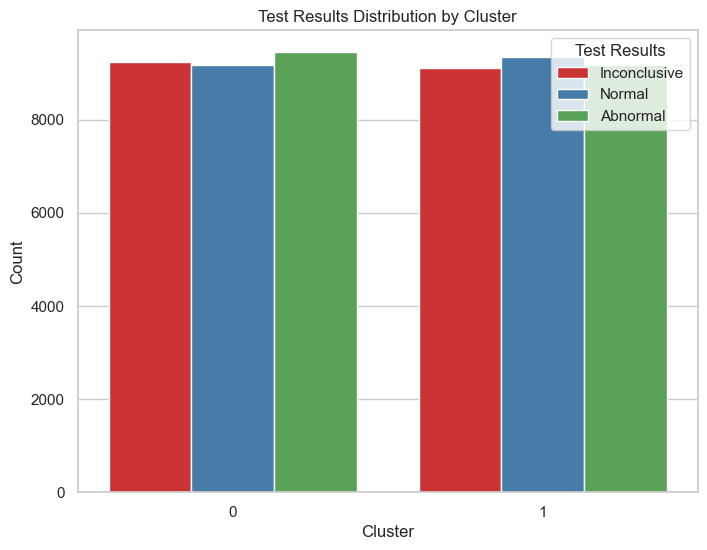

In [198]:
test_results_by_cluster = pd.crosstab(df['Cluster'], df['Test_Results_Label'])
print("\nTest Results Distribution by Cluster:")
print(test_results_by_cluster)

plt.figure(figsize=(8,6))
sns.countplot(x="Cluster", hue="Test_Results_Label", data=df, palette="Set1")
plt.title("Test Results Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Test Results")
plt.show()